# Inversions

  When debugging issues or testing configurations, it may be advantagous to run Isofit in a more controlled manner than the end-to-end Apply OE pipeline. This notebook gives a quick introduction to the structure of Isofit and how it can be used more like a Python package.

NOTE: Isofit is actively developed, so while we try to make sure that Apply OE is stable from a CLI standpoint, individual functions are subject to change.

We'll start with the small image cube example from before.

In [1]:
# Comon Imports
from pathlib import Path
from pprint import pprint
import warnings
warnings.filterwarnings("ignore")

from matplotlib import pyplot as plt
import numpy as np
from scipy.linalg import block_diag
from spectral import envi
from isofit.core.common import envi_header, load_esd, svd_inv_sqrt, load_wavelen
from isofit.core.isofit import Isofit
from isofit.data import env
from isofit.configs import configs
from isofit.core.forward import ForwardModel
from isofit.surface.surface import Surface
from isofit.core.instrument import Instrument
from isofit.inversion.inverse import Inversion
from isofit.core.geometry import Geometry
from isofit.core.fileio import IO


We load the data corresponding to radiance, location, and observation metadata files.

In [3]:
tutorial_path = "/Users/drt/Desktop/to_save/26EARSEL/tutorial/EARSeL_ISOFIT_Tutorial"
fid = "ENMAP01-____L1C-DT0000025905_20230707T192008Z_001_V010303_20230922T131737Z"
name = "Nevada"
output = f"{tutorial_path}/medium_example/{name}"

We now initialize the configuration object from a template, as before

In [4]:
config_file = f'{output}/config/{fid.split("_")[-4]}_isofit.json.tmpl'
resolved_config_file = env.fromTemplate(config_file, working_directory=output)
config = configs.create_new_config(resolved_config_file)

Now build the forward model and inverse model objects.  

In [5]:
fm = ForwardModel(config)
io = IO(config, fm)
wl, fwhm = load_wavelen(config.forward_model.instrument.wavelength_file)

Finally, extract radiance data and observation geometry for a pixel.

In [20]:
dat = io.get_components_at_index(10,0)
meas = dat.meas
geom = dat.geom

print("Solar zenith angle at this location:", geom.solar_zenith)
print("Viewer azimuth:",geom.observer_azimuth)
print("Cosine of the surface incidence angle:",geom.cos_i)

Solar zenith angle at this location: 16.64164200000002
Viewer azimuth: 13.095659021999989
Cosine of the surface incidence angle: 0.8023839329145401


Now we perform the inversion.  The invert function makes a heuristic guess to initialize the state vector.  It then returns a list of state vectors representing the iterative path to the converged state.  

In [7]:
iv = Inversion(config, fm)
solution = iv.invert(meas, geom)
print(f"Number of iterations to convergence: {len(solution)}")

Number of iterations to convergence: 7


We unpack the state vector into surface and atmosphere sub-vectors.  The vectors generally come in the order: 
  [surface_state_vector, 
   atmosphere_state_vector,
   instrument_state_vector]

Here the surface state has one reflectance value per instrument channel. We also have two atmospheric state variables and no instrument state variables, so there are n+2 elements for our n channel spectrometer. 

In [8]:
n = len(wl)
initial_x = solution[0,:]
surface_trajectory = solution[:,:n]
atmosphere_trajectory = solution[:,n:]

best_x = solution[-1,:]
best_surface = solution[-1,:n]
best_atmosphere = solution[-1,n:]

Now plot the convergence in surface and atmosphere portions of the state vector.

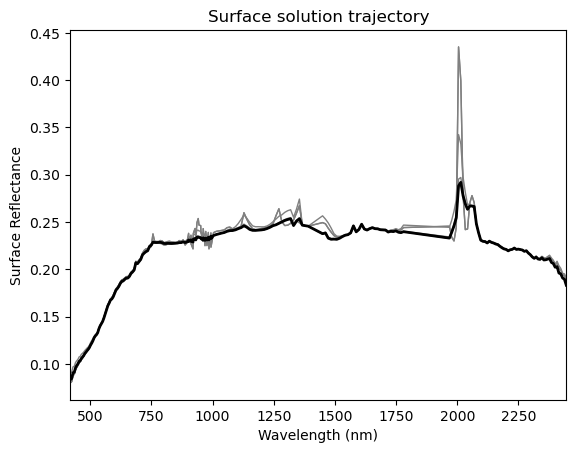

In [9]:
plt.plot(wl,surface_trajectory.T,'gray',lw=1)
plt.plot(wl, best_surface, 'k',lw=2)
plt.xlim([wl[0],wl[-1]])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Surface Reflectance');
plt.title('Surface solution trajectory');

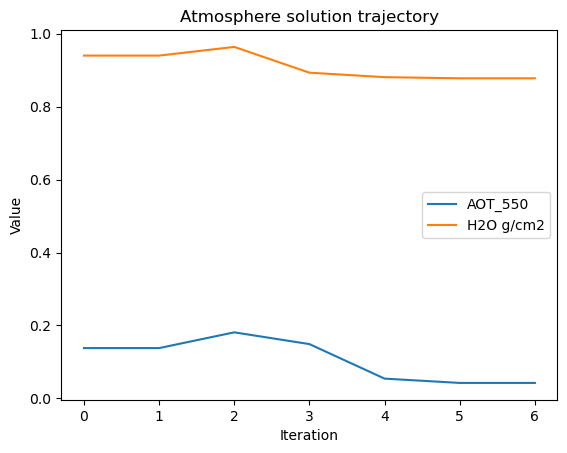

In [10]:
plt.plot(atmosphere_trajectory)
plt.title('Atmosphere solution trajectory')
plt.legend(('AOT_550','H2O g/cm2'))
plt.xlabel('Iteration')
plt.ylabel('Value');

To calculate the model radiance, we take our solution state and call the familar forward model function:

In [11]:
model_radiance = fm.calc_meas(best_x, geom)

Plot the model atmosphere and the measurement atmosphere to show the residual. 

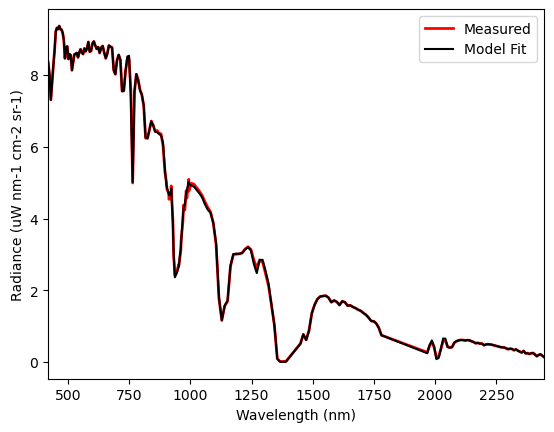

In [12]:
plt.plot(wl, meas, 'r', lw=2)
plt.plot(wl, model_radiance, 'k')
plt.xlim([wl[0],wl[-1]])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Radiance (uW nm-1 cm-2 sr-1)')
plt.legend(('Measured','Model Fit'));

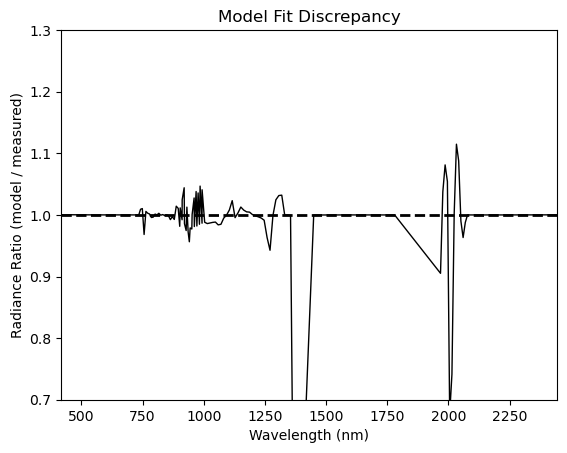

In [13]:
plt.plot(wl, model_radiance/meas, 'k', lw=1)
plt.plot(wl, np.ones_like(wl), 'k--',lw=2)
plt.xlim([wl[0],wl[-1]])
plt.ylim([0.7,1.3])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Radiance Ratio (model / measured)');
plt.title('Model Fit Discrepancy');

# Modifying surface priors

Let's take a look at the surface prior distribution, make some modifications, and see what happens.  Our surface priors are represented as a collection of multivariate Gaussian distributions, each defined by a mean vector $\mu$ and a covariance matrix $\Sigma$.  By having several multivariate Gaussians, we can more accurately model the statistics of surface types.

We first use the surface model's built-in distance function to identify which multivariate Gaussian this first guess is associated with.  Let's plot the mean and covariance.  

Note that we have elected a configuration choice where both means and covariances are stored in a normalized format and then scaled to match the magnitude of any first guess.  This approach causes the covariances and means to constrain the shape, rather than the overall magnitude, of the retrieved surface reflectance.  Directional surface reflectances can change in apparent magnitude due to photometric effects.

Text(0.5, 1.0, 'Log prior covariance - original')

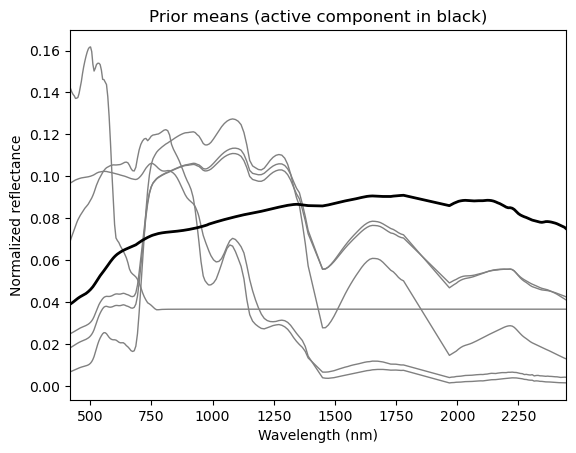

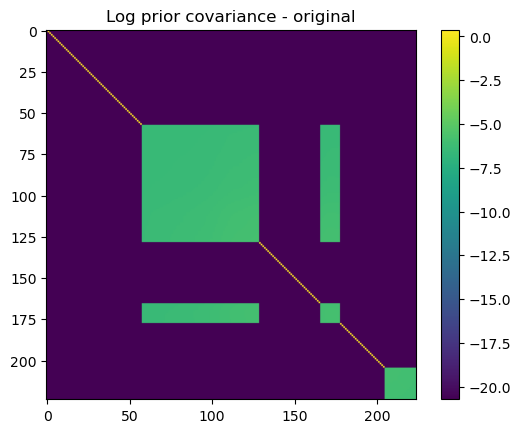

In [14]:
# Find the library index corresponding to our spectrum
component = fm.surface.component(initial_x, geom)

mean = fm.surface.component_means[component]

for i in range(len(fm.surface.component_means)):
    plt.plot(wl,fm.surface.component_means[i],'gray',lw=1)
plt.plot(wl,mean,'k',lw=2)
plt.xlim([wl[0],wl[-1]])
plt.title('Prior means (active component in black)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized reflectance')


Cov = fm.surface.component_covs[component]

plt.figure()
plt.imshow(np.log(Cov+1e-9))
plt.colorbar()
plt.title('Log prior covariance - original')

Now, let's make a modification to the covariance, removing the off-diagonal elements from a range of wavelengths that are currently autocorrelated.

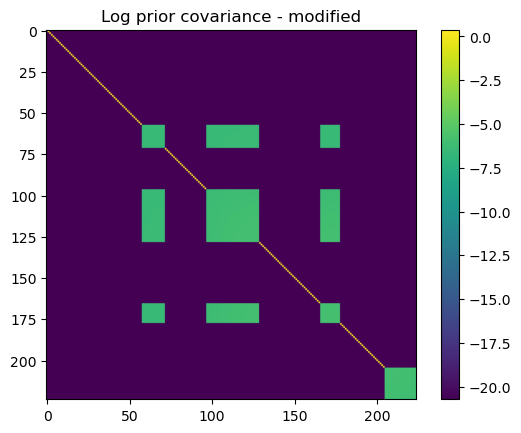

In [15]:
regularizer = Cov[0,0]

# Find band indices corresponding to the range between two wavelengths
start_wl, end_wl = 850,980
start_idx = np.argmin(abs(wl-start_wl))
end_idx = np.argmin(abs(wl-end_wl))

# Decorrelate these channels, but keep the diagonal 
for i in range(start_idx, end_idx):
    Cov[i,:]=0
    Cov[:,i]=0
    Cov[i,i]=regularizer

plt.figure()
plt.imshow(np.log(Cov+1e-9))
plt.colorbar()
plt.title('Log prior covariance - modified');

Now, we update the surface object. The typical way to do this is to modify the ".json" configuration and then use it to rebuild a "*.mat" surface file using the command line argument:

<code>$ isofit surface_model [--wavelength_path <wavelengths.txt>] [--output_path <output.mat>] \<config.json\> </code>

Or, alternatively, via a direct call to isofit.utils.surface_model:surface_model().

Here we are doing the modification in place, so we have to manually redo some caching operations to make sure the bookkeeping is consistent.  We also have to build some additional covariance structures that handle situations where the surface state vector has additional elements beyond the reflectance channels.  This machinery is normally hidden from the user during standard operations.

In [16]:
fm.surface.component_covs[component] = Cov.copy()

# Cache the subwindows that are actually used
fm.surface.Covs[component] = np.array([Cov[j, fm.surface.idx_ref] for j in fm.surface.idx_ref])
fm.surface.Cinvs[component] = svd_inv_sqrt(Cov)[0]

# Handle the fact that some surface state vectors contain extra elements
nprefix = fm.surface.idx_lamb[0]
nsuffix = len(fm.surface.statevec_names) - fm.surface.idx_lamb[-1] - 1
Cov_full = block_diag(
    np.zeros((nprefix, nprefix)),
    fm.surface.component_covs[component],
    np.zeros((nsuffix, nsuffix)),
)

# Cache the normalized Sa inv and Sa inv sqrt
Cov_normalized = Cov_full / np.mean(np.diag(Cov_full))
Cinv_normalized, Cinv_sqrt_normalized = svd_inv_sqrt(Cov_normalized)
fm.surface.Sa_inv_normalized[component] = Cinv_normalized
fm.surface.Sa_inv_sqrt_normalized[component] = Cinv_sqrt_normalized

We rerun the inversion using the modified surface priors

In [17]:
new_solution = iv.invert(meas, geom)
print(f"Number of iterations to convergence: {len(new_solution)}")

new_best_x = new_solution[-1,:]
new_best_surface = new_solution[-1,:len(wl)]
new_best_atmosphere = new_solution[-1,len(wl):];

Number of iterations to convergence: 7


Now, we plot the result and compare it to our previous one.  Interestingly, regions of the spectrum change outside the region where the priors were modified.  Why?

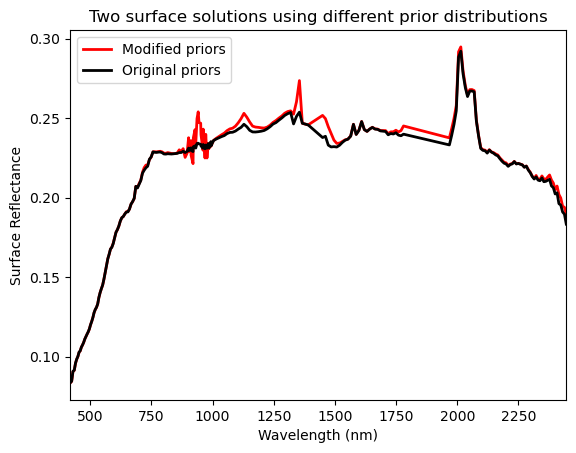

In [18]:
plt.plot(wl, new_best_surface,'r', lw=2)
plt.plot(wl, best_surface, 'k',lw=2)
plt.xlim([wl[0],wl[-1]])
plt.legend(('Modified priors','Original priors'))
plt.xlabel('Wavelength (nm)')
plt.ylabel('Surface Reflectance');
plt.title('Two surface solutions using different prior distributions');

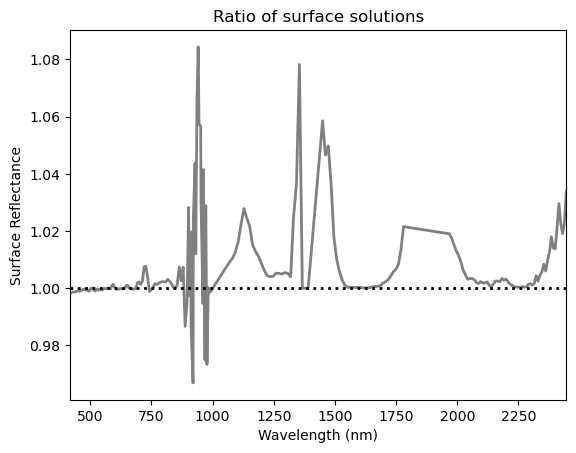

In [19]:
plt.plot(wl, new_best_surface/best_surface, 'gray',lw=2)
plt.plot(wl, np.ones_like(wl),'k:', lw=2)
plt.xlim([wl[0],wl[-1]])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Surface Reflectance');
plt.title('Ratio of surface solutions');